# DeepInsightors Team
### SPE DSEATS AFRICA - DATATHON 2025
### Contributors
* **Prof. S.0. OLATUNJI (AADAM)**
* **CHINONSO ATHANASIUS**
* **ZAYNAB ABDULROHEEM**
* **ABDULLAAH AADAM**

# A. Data Preparation & Cleaning
**Import Libraries**

In [1]:
# Basic Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load datasets
wells_df = pd.read_csv("spe_africa_dseats_datathon_2025_wells_dataset.csv")
reservoir_df = pd.read_csv("reservoir_info.csv")
class_df = pd.read_csv("classification_parameters.csv")

In [3]:
print("Shape:", wells_df.shape)
wells_df.head()

Shape: (7955, 13)


,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL)
0,15-Feb-14,Well_#1,0.0,"4,050",189.866,0,1.17951,482.46,50.864,0,0,0,0
1,16-Feb-14,Well_#1,0.0,"3,961",189.945,0,2.99440,328.601,47.668,0,0,0,0
2,17-Feb-14,Well_#1,0.0,"3,961",190.004,0,1.90349,387.218,48.962,0,0,0,0
3,18-Feb-14,Well_#1,0.0,"3,964",190.020,0,0.00000,308.98,46.636,0,0,0,0
4,19-Feb-14,Well_#1,0.0,"3,965",190.107,0,30.20760,196.057,47.297,0,0,0,0


In [4]:
print("Shape:", reservoir_df.shape)
reservoir_df.head()

Shape: (5, 6)


,Reservoir Name,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Current Average Reservoir Pressure (PSI),Solution Gas-Oil-Ratio (SCF/BBL),Formation Volume Factor (RB/STB)
0,ACHI,"3,500","3,300","2,700",800,1.20
1,KEMA,"4,200","4,000","3,900",600,1.45
2,MAKO,"3,500","3,500","3,000",500,1.15
3,DEPU,"2,800","2,800","2,400","1,200",1.37
4,JANI,"4,500","4,300","4,200","1,000",1.30


In [5]:
print("Shape:", class_df.shape)
class_df.head()

Shape: (5, 7)


,Reservoir Name,Reservoir Type,Well Type,Production Type,Formation GOR Trend,Watercut Trend,Oil Productivity Index Trend
0,ACHI,Saturated,NF,Steady,aSolGOR,Flat,Flat
1,KEMA,Undersat,GL,Unsteady,bSolGOR,Incr,Incr
2,MAKO,NaN,NaN,NaN,Combo,Decr,Decr
3,DEPU,NaN,NaN,NaN,NaN,Combo,Combo
4,JANI,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
wells_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7955 entries, 0 to 7954
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   PROD_DATE                             7955 non-null   object 
 1   WELL_NAME                             7955 non-null   object 
 2   ON_STREAM_HRS                         7955 non-null   float64
 3   BOTTOMHOLE_FLOWING_PRESSURE (PSI)     7955 non-null   object 
 4   DOWNHOLE_TEMPERATURE (deg F)          7955 non-null   float64
 5   ANNULUS_PRESS (PSI)                   7955 non-null   object 
 6   CHOKE_SIZE (%)                        7955 non-null   float64
 7   WELL_HEAD_PRESSURE (PSI)              7955 non-null   object 
 8   WELL_HEAD_TEMPERATURE (deg F)         7955 non-null   float64
 9   CUMULATIVE_OIL_PROD (STB)             7955 non-null   object 
 10  CUMULATIVE_FORMATION_GAS_PROD (MSCF)  7955 non-null   object 
 11  CUMULATIVE_TOTAL_

In [7]:
wells_df.describe()

,ON_STREAM_HRS,DOWNHOLE_TEMPERATURE (deg F),CHOKE_SIZE (%),WELL_HEAD_TEMPERATURE (deg F)
count,7955.000000,7955.000000,7955.000000,7955.000000
mean,21.623497,168.757429,56.155295,86.836365
std,6.567826,31.917787,34.975408,22.738615
min,0.000000,0.000000,0.000000,0.000000
25%,24.000000,150.228500,28.130855,80.677500
50%,24.000000,158.624000,51.068030,88.364000
75%,24.000000,202.600000,99.800950,96.770500
max,25.000000,212.153000,100.000000,182.157000


## Data Cleaning

**Rename columns for easier handling**

In [8]:
# Rename columns for easier handling
rename_map = {
    "PROD_DATE": "date",
    "WELL_NAME": "well_name",
    "ON_STREAM_HRS": "on_stream_hrs",
    "BOTTOMHOLE_FLOWING_PRESSURE (PSI)": "bhp",
    "DOWNHOLE_TEMPERATURE (deg F)": "downhole_temp",
    "ANNULUS_PRESS (PSI)": "annulus_p",
    "CHOKE_SIZE (%)": "choke_size",
    "WELL_HEAD_PRESSURE (PSI)": "whp",
    "WELL_HEAD_TEMPERATURE (deg F)": "wht",
    "CUMULATIVE_OIL_PROD (STB)": "cum_oil",
    "CUMULATIVE_FORMATION_GAS_PROD (MSCF)": "cum_form_gas",
    "CUMULATIVE_TOTAL_GAS_PROD (MSCF)": "cum_total_gas",
    "CUMULATIVE_WATER_PROD (BBL)": "cum_water"
}
wells_df.rename(columns=rename_map, inplace=True)

In [9]:
wells_df.head()

,date,well_name,on_stream_hrs,bhp,downhole_temp,annulus_p,choke_size,whp,wht,cum_oil,cum_form_gas,cum_total_gas,cum_water
0,15-Feb-14,Well_#1,0.0,"4,050",189.866,0,1.17951,482.46,50.864,0,0,0,0
1,16-Feb-14,Well_#1,0.0,"3,961",189.945,0,2.99440,328.601,47.668,0,0,0,0
2,17-Feb-14,Well_#1,0.0,"3,961",190.004,0,1.90349,387.218,48.962,0,0,0,0
3,18-Feb-14,Well_#1,0.0,"3,964",190.020,0,0.00000,308.98,46.636,0,0,0,0
4,19-Feb-14,Well_#1,0.0,"3,965",190.107,0,30.20760,196.057,47.297,0,0,0,0


In [10]:
# Clean numeric fields (remove commas, convert to float)
for col in ["bhp","annulus_p","whp","cum_oil","cum_form_gas","cum_total_gas","cum_water"]:
    wells_df[col] = wells_df[col].astype(str).str.replace(",", "").astype(float)

In [11]:
# Convert date
wells_df["date"] = pd.to_datetime(wells_df["date"], format="%d-%b-%y", errors="coerce")

In [12]:
# Clean well names
wells_df["well_name"] = wells_df["well_name"].str.replace("Well_#", "").astype(int)

In [13]:
wells_df.head()

,date,well_name,on_stream_hrs,bhp,downhole_temp,annulus_p,choke_size,whp,wht,cum_oil,cum_form_gas,cum_total_gas,cum_water
0,2014-02-15,1,0.0,4050.0,189.866,0.0,1.17951,482.460,50.864,0.0,0.0,0.0,0.0
1,2014-02-16,1,0.0,3961.0,189.945,0.0,2.99440,328.601,47.668,0.0,0.0,0.0,0.0
2,2014-02-17,1,0.0,3961.0,190.004,0.0,1.90349,387.218,48.962,0.0,0.0,0.0,0.0
3,2014-02-18,1,0.0,3964.0,190.020,0.0,0.00000,308.980,46.636,0.0,0.0,0.0,0.0
4,2014-02-19,1,0.0,3965.0,190.107,0.0,30.20760,196.057,47.297,0.0,0.0,0.0,0.0


**Check for Missing Values**

In [14]:
wells_df.isnull().sum()

date             0
well_name        0
on_stream_hrs    0
bhp              0
downhole_temp    0
annulus_p        0
choke_size       0
whp              0
wht              0
cum_oil          0
cum_form_gas     0
cum_total_gas    0
cum_water        0
dtype: int64

**Check for Duplicates**

In [15]:
wells_df.duplicated().sum()

0

### Renaming Reservoir data columns

In [16]:
reservoir_df.columns

Index(['Reservoir Name', 'Initial Reservoir Pressure (PSI)',
       'Bubble Point Pressure (PSI)',
       'Current Average Reservoir Pressure (PSI)',
       'Solution Gas-Oil-Ratio (SCF/BBL)', 'Formation Volume Factor (RB/STB)'],
      dtype='object')

In [17]:
# Rename columns for easier handling
reservoir_map = {
    "Reservoir Name": "Reservoir Name",
    "Initial Reservoir Pressure (PSI)": "Initial_PSI",
    "Bubble Point Pressure (PSI)": "Bubble_PSI",
    "Current Average Reservoir Pressure (PSI)": "Current_PSI",
    "Solution Gas-Oil-Ratio (SCF/BBL)": "Solution_GOR",
    "Formation Volume Factor (RB/STB)": "Formation_Factor"
}
reservoir_df.rename(columns=reservoir_map, inplace=True)

In [18]:
reservoir_df

,Reservoir Name,Initial_PSI,Bubble_PSI,Current_PSI,Solution_GOR,Formation_Factor
0,ACHI,"3,500","3,300","2,700",800,1.20
1,KEMA,"4,200","4,000","3,900",600,1.45
2,MAKO,"3,500","3,500","3,000",500,1.15
3,DEPU,"2,800","2,800","2,400","1,200",1.37
4,JANI,"4,500","4,300","4,200","1,000",1.30


# B. Empirical Analysis (Feature Engineering Calculations)

### Daily production

In [19]:
# Daily production
wells_df["oil_day"] = wells_df.groupby("well_name")["cum_oil"].diff()
wells_df["gas_day"] = wells_df.groupby("well_name")["cum_total_gas"].diff()
wells_df["water_day"] = wells_df.groupby("well_name")["cum_water"].diff()

Daily production columns added:


,date,well_name,oil_day,gas_day,water_day
0,2014-02-15,1,NaN,NaN,NaN
1,2014-02-16,1,0.0,0.0,0.0
2,2014-02-17,1,0.0,0.0,0.0
3,2014-02-18,1,0.0,0.0,0.0
4,2014-02-19,1,0.0,0.0,0.0
5,2014-02-20,1,0.0,0.0,0.0
6,2014-02-21,1,0.0,0.0,0.0
7,2014-02-22,1,0.0,0.0,0.0
8,2014-02-23,1,0.0,0.0,0.0
9,2014-02-24,1,0.0,0.0,0.0


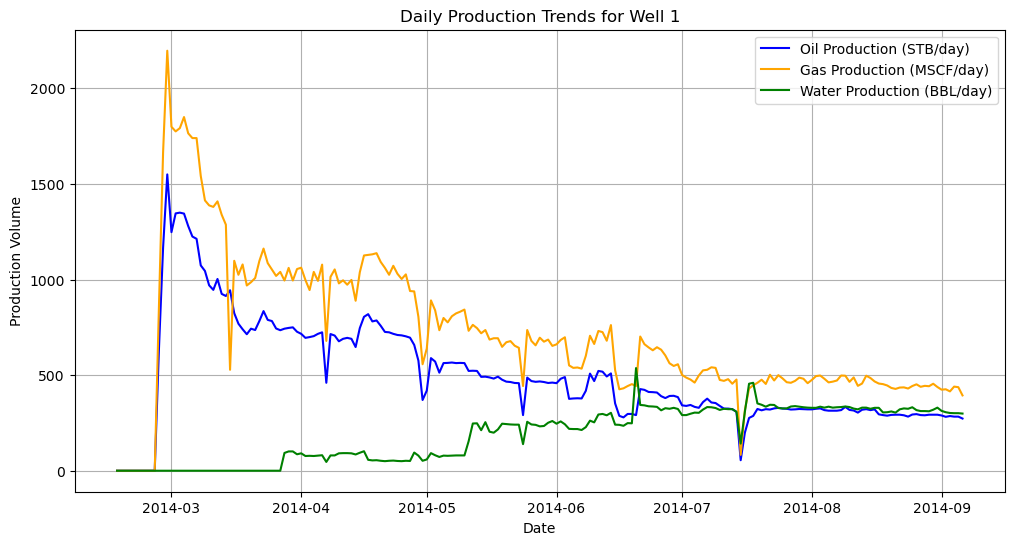

In [20]:
# Display first few rows to check calculations
print("Daily production columns added:")
display(wells_df[["date","well_name","oil_day","gas_day","water_day"]].head(20))

# Quick visualization for one well
subset = wells_df[wells_df["well_name"]==1].sort_values("date")
plt.figure(figsize=(12,6))
plt.plot(subset["date"], subset["oil_day"], label="Oil Production (STB/day)", color="blue")
plt.plot(subset["date"], subset["gas_day"], label="Gas Production (MSCF/day)", color="orange")
plt.plot(subset["date"], subset["water_day"], label="Water Production (BBL/day)", color="green")
plt.title("Daily Production Trends for Well 1")
plt.xlabel("Date")
plt.ylabel("Production Volume")
plt.legend()
plt.grid(True)
plt.show()


# 1. Reservoir Identification
**Fix Reservoir Data Types**

In [21]:
reservoir_df.head()

,Reservoir Name,Initial_PSI,Bubble_PSI,Current_PSI,Solution_GOR,Formation_Factor
0,ACHI,"3,500","3,300","2,700",800,1.20
1,KEMA,"4,200","4,000","3,900",600,1.45
2,MAKO,"3,500","3,500","3,000",500,1.15
3,DEPU,"2,800","2,800","2,400","1,200",1.37
4,JANI,"4,500","4,300","4,200","1,000",1.30


In [22]:
# Convert reservoir numeric columns to float
for col in ["Initial_PSI",
            "Bubble_PSI",
            "Current_PSI",
            "Solution_GOR"]:
    reservoir_df[col] = reservoir_df[col].astype(str).str.replace(",", "").astype(float)

# Check types
print(reservoir_df.dtypes)
display(reservoir_df)

Reservoir Name       object
Initial_PSI         float64
Bubble_PSI          float64
Current_PSI         float64
Solution_GOR        float64
Formation_Factor    float64
dtype: object


,Reservoir Name,Initial_PSI,Bubble_PSI,Current_PSI,Solution_GOR,Formation_Factor
0,ACHI,3500.0,3300.0,2700.0,800.0,1.20
1,KEMA,4200.0,4000.0,3900.0,600.0,1.45
2,MAKO,3500.0,3500.0,3000.0,500.0,1.15
3,DEPU,2800.0,2800.0,2400.0,1200.0,1.37
4,JANI,4500.0,4300.0,4200.0,1000.0,1.30


**Reservoir Identification Function code**

In [23]:
# Reservoir Identification
def assign_reservoir(max_bhp, reservoir_df, tolerance=200):
    for _, row in reservoir_df.iterrows():
        diff = row["Initial_PSI"] - max_bhp
        if 0 <= diff <= tolerance:
            return row["Reservoir Name"]
    return None

**Apply Reservoir Identification function code**

In [24]:
# Calculate max bottomhole pressure per well
max_bhp_df = wells_df.groupby("well_name")["bhp"].max().reset_index()
max_bhp_df.rename(columns={"bhp":"max_bhp"}, inplace=True)

# Assign reservoir for each well
max_bhp_df["Reservoir"] = max_bhp_df["max_bhp"].apply(lambda x: assign_reservoir(x, reservoir_df))

# Display first 20 wells with reservoir assignment
print("Reservoir assignment based on max bottomhole pressure:")
display(max_bhp_df.head(20))

Reservoir assignment based on max bottomhole pressure:


,well_name,max_bhp,Reservoir
0,1,4096.0,KEMA
1,2,3735.0,None
2,3,2985.0,None
3,4,2340.0,None
4,5,2933.0,None
5,6,3797.0,None
6,7,3821.0,None
7,8,2681.0,DEPU
8,9,2333.0,None
9,10,4051.0,KEMA


**Visualize Reservoir Assignment**

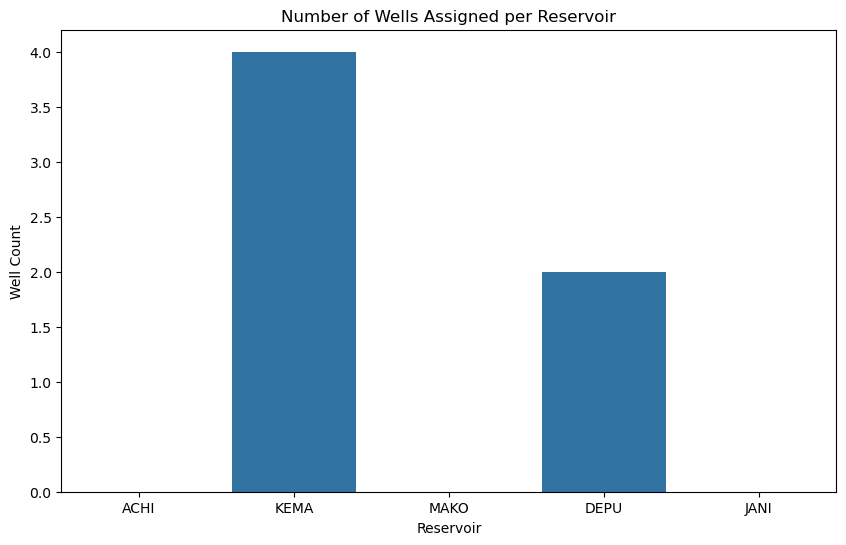

In [25]:
# Bar plot of wells assigned to reservoirs
plt.figure(figsize=(10,6))
sns.countplot(x="Reservoir", data=max_bhp_df, order=reservoir_df["Reservoir Name"])
plt.title("Number of Wells Assigned per Reservoir")
plt.xlabel("Reservoir")
plt.ylabel("Well Count")
plt.show()

# Observation
The issue is that the strict ≤200 psi cutoff only matches a few wells which are (KEMA and DEPU). Instead, we’ll assign each well to the closest reservoir pressure (Initial or Current Average), which guarantees every well is classified.

**Reservoir Identification (Closest Reservoir)**

In [26]:
def assign_reservoir_closest(max_bhp, reservoir_df, use_current=True):
    """
    Assign reservoir based on closest pressure match.
    If use_current=True, compare against current average reservoir pressure.
    Otherwise, use initial reservoir pressure.
    """
    if use_current:
        diffs = reservoir_df["Current_PSI"] - max_bhp
    else:
        diffs = reservoir_df["Initial_PSI"] - max_bhp
    
    # Only consider positive differences (reservoir pressure >= BHP)
    diffs = diffs[diffs >= 0]
    if len(diffs) == 0:
        return "Unassigned"
    
    closest_idx = diffs.idxmin()
    return reservoir_df.loc[closest_idx, "Reservoir Name"]

**Apply Reservoir Identification**

In [27]:
# Calculate max bottomhole pressure per well
max_bhp_df = wells_df.groupby("well_name")["bhp"].max().reset_index()
max_bhp_df.rename(columns={"bhp": "max_bhp"}, inplace=True)

# Assign reservoir using closest pressure match
max_bhp_df["Reservoir Name"] = max_bhp_df["max_bhp"].apply(
    lambda x: assign_reservoir_closest(x, reservoir_df, use_current=True)
)

# Merge results back into wells_df
wells_df = wells_df.merge(max_bhp_df, on="well_name", how="left")

In [28]:
# Inspect updated dataset
wells_df

,date,well_name,on_stream_hrs,bhp,downhole_temp,annulus_p,choke_size,whp,wht,cum_oil,cum_form_gas,cum_total_gas,cum_water,oil_day,gas_day,water_day,max_bhp,Reservoir Name
0,2014-02-15,1,0.00,4050.0,189.866,0.000,1.17951,482.460,50.864,0.0,0.0,0.0,0.0,NaN,NaN,NaN,4096.0,JANI
1,2014-02-16,1,0.00,3961.0,189.945,0.000,2.99440,328.601,47.668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4096.0,JANI
2,2014-02-17,1,0.00,3961.0,190.004,0.000,1.90349,387.218,48.962,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4096.0,JANI
3,2014-02-18,1,0.00,3964.0,190.020,0.000,0.00000,308.980,46.636,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4096.0,JANI
4,2014-02-19,1,0.00,3965.0,190.107,0.000,30.20760,196.057,47.297,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4096.0,JANI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7950,2015-04-05,20,18.94,2505.0,149.177,633.188,77.32078,115.406,85.532,497425.0,235131.0,352697.0,522788.0,170.0,101.0,445.0,2858.0,MAKO
7951,2015-04-06,20,21.06,2503.0,149.169,617.591,72.40304,116.285,84.959,497609.0,235205.0,352808.0,523266.0,184.0,111.0,478.0,2858.0,MAKO
7952,2015-04-07,20,24.00,2481.0,149.175,645.435,100.00000,111.943,87.361,497879.0,235314.0,352971.0,523885.0,270.0,163.0,619.0,2858.0,MAKO
7953,2015-04-08,20,15.94,2485.0,149.178,651.282,76.40842,111.962,87.583,498019.0,235370.0,353055.0,524431.0,140.0,84.0,546.0,2858.0,MAKO


In [29]:
wells_df.groupby('well_name')['Reservoir Name'].max().reset_index()

,well_name,Reservoir Name
0,1,JANI
1,2,KEMA
2,3,MAKO
3,4,DEPU
4,5,MAKO
5,6,KEMA
6,7,KEMA
7,8,ACHI
8,9,DEPU
9,10,JANI


### Summary
* Instead of requiring a strict ≤200 psi difference, we now assign each well to the closest reservoir pressure.
* This ensures all wells are classified into one of the five reservoirs.

## 2. Reservoir Type Classification
**Define Reservoir Type Function**

In [30]:
# Reservoir Type classification
def check_saturation(res_row):
    """
    Reservoir is Saturated if Initial Pressure <= Bubble Point Pressure,
    otherwise Undersaturated.
    """
    return "Saturated" if res_row["Initial_PSI"] <= res_row["Bubble_PSI"] else "Undersat"

**Apply Reservoir Type to All Reservoirs**

In [31]:
# Apply saturation check to each reservoir row
reservoir_df["Reservoir Type"] = reservoir_df.apply(check_saturation, axis=1)

# Display results
print("Reservoir Type Classification:")
display(reservoir_df[["Reservoir Name","Initial_PSI","Bubble_PSI","Reservoir Type"]])

Reservoir Type Classification:


,Reservoir Name,Initial_PSI,Bubble_PSI,Reservoir Type
0,ACHI,3500.0,3300.0,Undersat
1,KEMA,4200.0,4000.0,Undersat
2,MAKO,3500.0,3500.0,Saturated
3,DEPU,2800.0,2800.0,Saturated
4,JANI,4500.0,4300.0,Undersat


In [32]:
# Merge results back into wells_df
wells_df = wells_df.merge(reservoir_df, on="Reservoir Name", how="left")

In [33]:
wells_df

,date,well_name,on_stream_hrs,bhp,downhole_temp,annulus_p,choke_size,whp,wht,cum_oil,...,gas_day,water_day,max_bhp,Reservoir Name,Initial_PSI,Bubble_PSI,Current_PSI,Solution_GOR,Formation_Factor,Reservoir Type
0,2014-02-15,1,0.00,4050.0,189.866,0.000,1.17951,482.460,50.864,0.0,...,NaN,NaN,4096.0,JANI,4500.0,4300.0,4200.0,1000.0,1.30,Undersat
1,2014-02-16,1,0.00,3961.0,189.945,0.000,2.99440,328.601,47.668,0.0,...,0.0,0.0,4096.0,JANI,4500.0,4300.0,4200.0,1000.0,1.30,Undersat
2,2014-02-17,1,0.00,3961.0,190.004,0.000,1.90349,387.218,48.962,0.0,...,0.0,0.0,4096.0,JANI,4500.0,4300.0,4200.0,1000.0,1.30,Undersat
3,2014-02-18,1,0.00,3964.0,190.020,0.000,0.00000,308.980,46.636,0.0,...,0.0,0.0,4096.0,JANI,4500.0,4300.0,4200.0,1000.0,1.30,Undersat
4,2014-02-19,1,0.00,3965.0,190.107,0.000,30.20760,196.057,47.297,0.0,...,0.0,0.0,4096.0,JANI,4500.0,4300.0,4200.0,1000.0,1.30,Undersat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7950,2015-04-05,20,18.94,2505.0,149.177,633.188,77.32078,115.406,85.532,497425.0,...,101.0,445.0,2858.0,MAKO,3500.0,3500.0,3000.0,500.0,1.15,Saturated
7951,2015-04-06,20,21.06,2503.0,149.169,617.591,72.40304,116.285,84.959,497609.0,...,111.0,478.0,2858.0,MAKO,3500.0,3500.0,3000.0,500.0,1.15,Saturated
7952,2015-04-07,20,24.00,2481.0,149.175,645.435,100.00000,111.943,87.361,497879.0,...,163.0,619.0,2858.0,MAKO,3500.0,3500.0,3000.0,500.0,1.15,Saturated
7953,2015-04-08,20,15.94,2485.0,149.178,651.282,76.40842,111.962,87.583,498019.0,...,84.0,546.0,2858.0,MAKO,3500.0,3500.0,3000.0,500.0,1.15,Saturated


In [34]:
wells_df.groupby('well_name')['Reservoir Type'].max().reset_index()

,well_name,Reservoir Type
0,1,Undersat
1,2,Undersat
2,3,Saturated
3,4,Saturated
4,5,Saturated
5,6,Undersat
6,7,Undersat
7,8,Undersat
8,9,Saturated
9,10,Undersat


**Visualize Reservoir Types**

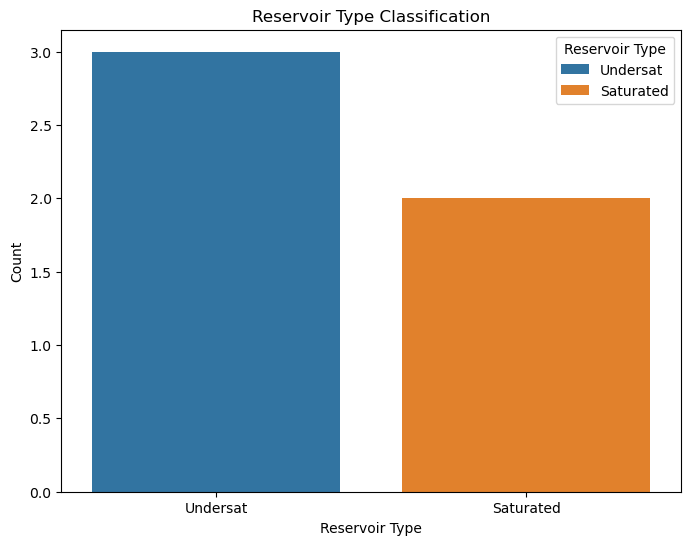

In [35]:
# Bar chart of reservoir types
plt.figure(figsize=(8,6))
sns.countplot(x="Reservoir Type", data=reservoir_df, hue="Reservoir Type", legend=True)
plt.title("Reservoir Type Classification")
plt.xlabel("Reservoir Type")
plt.ylabel("Count");

### Summary
* Function defined for reservoir type classification.
* Table output showing each reservoir’s initial pressure, bubble point, and type (Saturated/Undersat).

## 3. Flow Mechanism Classification
**Define Flow Mechanism Function**

In [36]:
# Flow Mechanism classification
def classify_well_type(subset):
    """
    Classify wells based on annulus pressure.
    GL = Gas Lift (if annulus pressure > 0)
    NF = Naturally Flowing (if annulus pressure = 0)
    """
    return "GL" if subset["annulus_p"].mean() > 0 else "NF"

**Apply Flow Mechanism to All Wells**

In [37]:

# Apply classification for each well
flow_results = []
for well in wells_df["well_name"].unique():
    subset = wells_df[wells_df["well_name"] == well]
    flow_results.append({
        "well_name": well,
        "Flow Mechanism": classify_well_type(subset)
    })

flow_df = pd.DataFrame(flow_results)

# Merge results back into wells_df
wells_df = wells_df.merge(flow_df, on="well_name", how="left")

In [38]:
wells_df.head()

,date,well_name,on_stream_hrs,bhp,downhole_temp,annulus_p,choke_size,whp,wht,cum_oil,...,water_day,max_bhp,Reservoir Name,Initial_PSI,Bubble_PSI,Current_PSI,Solution_GOR,Formation_Factor,Reservoir Type,Flow Mechanism
0,2014-02-15,1,0.0,4050.0,189.866,0.0,1.17951,482.460,50.864,0.0,...,NaN,4096.0,JANI,4500.0,4300.0,4200.0,1000.0,1.3,Undersat,GL
1,2014-02-16,1,0.0,3961.0,189.945,0.0,2.99440,328.601,47.668,0.0,...,0.0,4096.0,JANI,4500.0,4300.0,4200.0,1000.0,1.3,Undersat,GL
2,2014-02-17,1,0.0,3961.0,190.004,0.0,1.90349,387.218,48.962,0.0,...,0.0,4096.0,JANI,4500.0,4300.0,4200.0,1000.0,1.3,Undersat,GL
3,2014-02-18,1,0.0,3964.0,190.020,0.0,0.00000,308.980,46.636,0.0,...,0.0,4096.0,JANI,4500.0,4300.0,4200.0,1000.0,1.3,Undersat,GL
4,2014-02-19,1,0.0,3965.0,190.107,0.0,30.20760,196.057,47.297,0.0,...,0.0,4096.0,JANI,4500.0,4300.0,4200.0,1000.0,1.3,Undersat,GL


In [39]:
wells_df.groupby('well_name')['Flow Mechanism'].max().reset_index()

,well_name,Flow Mechanism
0,1,GL
1,2,NF
2,3,GL
3,4,GL
4,5,GL
5,6,GL
6,7,GL
7,8,GL
8,9,GL
9,10,GL


In [40]:
# Inspect Values of Flow Mechanism
wells_df['Flow Mechanism'].value_counts()

Flow Mechanism
GL    6919
NF    1036
Name: count, dtype: int64

**Visualize Flow Mechanism Distribution**

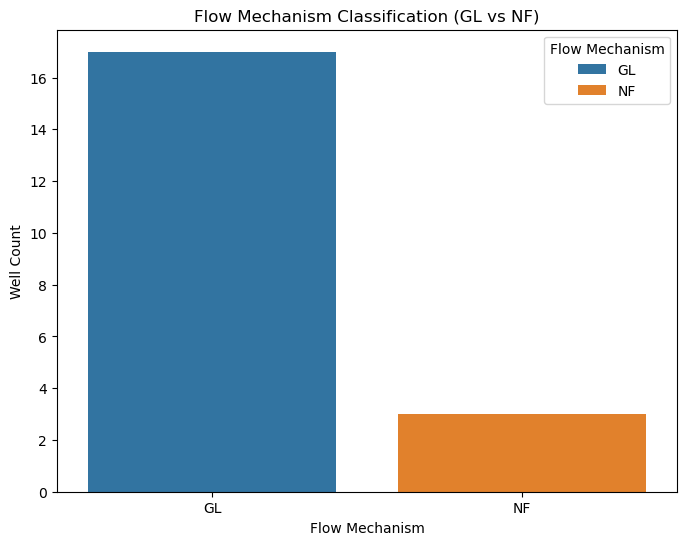

In [41]:
# Bar chart of flow mechanism types
plt.figure(figsize=(8,6))
sns.countplot(x="Flow Mechanism", data=flow_df, hue="Flow Mechanism", legend=True)
plt.title("Flow Mechanism Classification (GL vs NF)")
plt.xlabel("Flow Mechanism")
plt.ylabel("Well Count");

### Summary
* Function defined for flow mechanism classification.
* Table output showing each well and whether it is Gas Lift (GL) or Naturally Flowing (NF).

# C. Well Performance Analysis

## 1. Production Stability Classification

In [42]:
steady_unsteady_status = {}

# Get all wells
all_wells = wells_df['well_name'].unique()

for w_ in all_wells:
    wl = wells_df[wells_df['well_name'] == w_].copy()

    # Sort by date
    wl.sort_values('date', ascending=True, inplace=True)

    # Calculate rate drop percentage based on daily oil production
    wl['rate_drop'] = ((wl['oil_day'].shift(1) - wl['oil_day']) / 
                       (wl['oil_day'].shift(1) + 1e-6)) * 100

    # Get min and max dates
    min_date, max_date = wl.date.min(), wl.date.max()

    curr_date = min_date
    while curr_date < max_date:
        next_date = curr_date + pd.DateOffset(months=6)
        wl_window = wl[(wl['date'] > curr_date) & (wl['date'] <= next_date)]

        # Calculate time span in months
        date_diff = (wl_window['date'].max() - wl_window['date'].min()).days / 30

        # Maximum drop in this window
        max_drop = wl_window['rate_drop'].max()

        # Classification rule
        if max_drop > 50 and 3 <= date_diff <= 6.1:
            steady_unsteady_status[w_] = 'Unsteady'
            break
        else:
            steady_unsteady_status[w_] = 'Steady'
            break

        curr_date += pd.DateOffset(months=6)

# Convert results to DataFrame
stability_df = pd.DataFrame(list(steady_unsteady_status.items()), 
                            columns=['well_name','Production Stability'])

# Merge results back into wells_df
wells_df = wells_df.merge(stability_df, on='well_name', how='left')

In [43]:
# Inspect updated dataset
wells_df.head()

,date,well_name,on_stream_hrs,bhp,downhole_temp,annulus_p,choke_size,whp,wht,cum_oil,...,max_bhp,Reservoir Name,Initial_PSI,Bubble_PSI,Current_PSI,Solution_GOR,Formation_Factor,Reservoir Type,Flow Mechanism,Production Stability
0,2014-02-15,1,0.0,4050.0,189.866,0.0,1.17951,482.460,50.864,0.0,...,4096.0,JANI,4500.0,4300.0,4200.0,1000.0,1.3,Undersat,GL,Unsteady
1,2014-02-16,1,0.0,3961.0,189.945,0.0,2.99440,328.601,47.668,0.0,...,4096.0,JANI,4500.0,4300.0,4200.0,1000.0,1.3,Undersat,GL,Unsteady
2,2014-02-17,1,0.0,3961.0,190.004,0.0,1.90349,387.218,48.962,0.0,...,4096.0,JANI,4500.0,4300.0,4200.0,1000.0,1.3,Undersat,GL,Unsteady
3,2014-02-18,1,0.0,3964.0,190.020,0.0,0.00000,308.980,46.636,0.0,...,4096.0,JANI,4500.0,4300.0,4200.0,1000.0,1.3,Undersat,GL,Unsteady
4,2014-02-19,1,0.0,3965.0,190.107,0.0,30.20760,196.057,47.297,0.0,...,4096.0,JANI,4500.0,4300.0,4200.0,1000.0,1.3,Undersat,GL,Unsteady


In [44]:
wells_df.groupby('well_name')['Production Stability'].max().reset_index()

,well_name,Production Stability
0,1,Unsteady
1,2,Unsteady
2,3,Unsteady
3,4,Unsteady
4,5,Unsteady
5,6,Unsteady
6,7,Unsteady
7,8,Unsteady
8,9,Unsteady
9,10,Unsteady


In [45]:
wells_df['Production Stability'].value_counts()

Production Stability
Unsteady    7230
Steady       725
Name: count, dtype: int64

### Summary
* Function defined for production stability classification.
* Table output showing each well as Steady or Unsteady.

## 2. Gas–Oil Ratio (GOR) Trend classification
* **GOR = Cumulative Gas Produced / Cumulative Oil Produced**
* aSolGOR: If GOR increases consistently over time
* bSolGOR: If GOR decreases consistently
* Combo: If GOR fluctuates, or combination the two

$$
GOR = \frac{\text{Gas Production (MSCF)}}{\text{Oil Production (STB)}}
$$

In [ ]:
# Gas-Oil Ratio calculation
wells_df["gor_plot"] = wells_df["gas_day"] / wells_df["oil_day"].replace(0, np.nan)

# Plot GOR trends per well
def plot_gor(df):
    wells = df["well_name"].unique()
    fig, axes = plt.subplots(len(wells)//4, 4, figsize=(20, 15), constrained_layout=True)
    axes = axes.flatten()
    for i, well in enumerate(wells):
        subset = df[df["well_name"] == well].sort_values("date")
        axes[i].plot(subset["date"], subset["gor_plot"], color="orange")
        axes[i].set_title(f"Well {well} - GOR Trend")
        axes[i].set_xlabel("Date")
        axes[i].set_ylabel("GOR (scf/STB)")
        axes[i].grid()
    plt.show()

plot_gor(wells_df)

In [ ]:
def classify_gor_trend(subset, slope_threshold=0.0002, oscillation_threshold=0.65, min_points=5):
    """
    Classify GOR (Gas-Oil Ratio) trend for a given well subset.
    Returns one of: 'aSolGOR', 'bSolGOR', 'Combo'.
    """

    # Ensure chronological order
    subset = subset.sort_values("date")

    # Clean GOR series (replace zeros with NaN, drop missing)
    gor_series = subset["gor_plot"].replace(0, np.nan).dropna()

    # Not enough data → default classification
    if len(gor_series) < min_points:
        return "Combo"

    # Global slope (linear regression)
    x = np.arange(len(gor_series))
    slope = np.polyfit(x, gor_series, 1)[0]

    # Local oscillation (sign changes in differences)
    local_slopes = np.diff(gor_series)
    if len(local_slopes) > 1:
        sign_changes = np.sum(np.sign(local_slopes[:-1]) != np.sign(local_slopes[1:]))
        change_ratio = sign_changes / len(local_slopes)
    else:
        change_ratio = 0

    # Trend classification based on slope
    if slope > slope_threshold:
        trend = "aSolGOR"   # Increasing GOR
    elif slope < -slope_threshold:
        trend = "bSolGOR"   # Decreasing GOR
    else:
        trend = "Combo"     # Flat or mixed

    # Override if strong oscillation
    if change_ratio > oscillation_threshold:
        trend = "Combo"

    return trend


# Apply classification for each well
gor_results = [
    {"well_name": well, "GOR_Trend_Class": classify_gor_trend(subset)}
    for well, subset in wells_df.groupby("well_name")
]

# Merge results back into wells_df
gor_df = pd.DataFrame(gor_results)
wells_df = wells_df.merge(gor_df, on="well_name", how="left")

In [ ]:
wells_df['GOR_Trend_Class'].value_counts()

In [ ]:
wells_df.groupby('well_name')['GOR_Trend_Class'].max().reset_index()

## 3. Watercut Trend
* Flat: watercut remains steady
* Incr: watercut increases over time
* Decr: watercut decreases over time
* Combo: inconsistent or mixed trend

$$
\text{Watercut} = \frac{\text{Water Production}}{\text{Oil Production} + \text{Water Production}}
$$

In [ ]:
# Watercut calculation
wells_df["watercut"] = wells_df["water_day"] / (wells_df["oil_day"] + wells_df["water_day"]).replace(0, np.nan)

# Plot Watercut trends per well
def plot_watercut(df):
    wells = df["well_name"].unique()
    fig, axes = plt.subplots(len(wells)//4, 4, figsize=(20, 15), constrained_layout=True)
    axes = axes.flatten()
    for i, well in enumerate(wells):
        subset = df[df["well_name"] == well].sort_values("date")
        axes[i].plot(subset["date"], subset["watercut"], color="blue")
        axes[i].set_title(f"Well {well} - Watercut Trend")
        axes[i].set_xlabel("Date")
        axes[i].set_ylabel("Watercut (%)")
        axes[i].grid()
    plt.show()

plot_watercut(wells_df)

In [ ]:
def classify_watercut_trend(subset, slope_threshold=0.05, oscillation_threshold=0.65, min_points=5):
    """
    Classify watercut trend for a given well subset.
    Returns one of: 'Flat', 'Incre', 'Decre', 'Combo'.
    """

    # Ensure chronological order
    subset = subset.sort_values("date")

    # Clean watercut series (replace zeros with NaN, drop missing)
    wc_series = subset["water_day"].replace(0, np.nan).dropna()

    # Not enough data → default classification
    if len(wc_series) < min_points:
        return "Combo"

    # Global slope (linear regression)
    x = np.arange(len(wc_series))
    slope = np.polyfit(x, wc_series, 1)[0]

    # Local oscillation (sign changes in differences)
    local_slopes = np.diff(wc_series)
    if len(local_slopes) > 1:
        sign_changes = np.sum(np.sign(local_slopes[:-1]) != np.sign(local_slopes[1:]))
        change_ratio = sign_changes / len(local_slopes)
    else:
        change_ratio = 0

    # Trend classification
    if -slope_threshold <= slope <= slope_threshold:
        trend = "Flat"
    elif slope > slope_threshold:
        trend = "Incre"
    elif slope < -slope_threshold:
        trend = "Decre"
    else:
        trend = "Combo"

    # Override if strong oscillation
    if change_ratio > oscillation_threshold:
        trend = "Combo"

    return trend


# Apply classification for each well
watercut_results = [
    {"well_name": well, "Watercut_Trend_Class": classify_watercut_trend(subset)}
    for well, subset in wells_df.groupby("well_name")
]

# Merge results back into wells_df
watercut_df = pd.DataFrame(watercut_results)
wells_df = wells_df.merge(watercut_df, on="well_name", how="left")

In [ ]:
wells_df.groupby('well_name')['Watercut_Trend_Class'].max().reset_index()

In [ ]:
wells_df['Watercut_Trend_Class'].value_counts()

## 4 Productivity Index Trend
* Flat – no significant change in PI
* Incr – PI increasing over time
* Decr – PI decreasing over time
* Combo – inconsistent or mixed PI behavior

$$
PI = \frac{\text{Oil Production (STB/day)}}{\text{Reservoir Pressure} - \text{Bottomhole Pressure}}
$$

In [ ]:
# Create reservoir mapping
res_map = dict(zip(max_bhp_df["well_name"], max_bhp_df["Reservoir Name"]))
avg_pressures = dict(zip(reservoir_df["Reservoir Name"], reservoir_df["Current_PSI"]))

wells_df["pi"] = wells_df.apply(
    lambda row: row["oil_day"] / (row["bhp"] - avg_pressures.get(res_map.get(row["well_name"], ""), np.nan))
    if row["oil_day"] > 0 else np.nan, axis=1
)

# Plot PI trends per well
def plot_pi(df):
    wells = df["well_name"].unique()
    fig, axes = plt.subplots(len(wells)//4, 4, figsize=(20, 15), constrained_layout=True)
    axes = axes.flatten()
    for i, well in enumerate(wells):
        subset = df[df["well_name"] == well].sort_values("date")
        axes[i].plot(subset["date"], subset["pi"], color="green")
        axes[i].set_title(f"Well {well} - Productivity Index")
        axes[i].set_xlabel("Date")
        axes[i].set_ylabel("PI (STB/psi)")
        axes[i].grid()
    plt.show()

plot_pi(wells_df)

In [ ]:
def classify_pi_trend(subset, slope_threshold=0.001, oscillation_threshold=0.65, min_points=5):
    """
    Classify PI (Productivity Index) trend for a given well subset.
    Returns one of: 'Flat', 'Incre', 'Decre', 'Combo'.
    """

    # Ensure chronological order
    subset = subset.sort_values("date")

    # Clean PI series (replace zeros with NaN, drop missing)
    pi_series = subset["pi"].replace(0, np.nan).dropna()

    # Not enough data → default classification
    if len(pi_series) < min_points:
        return "Combo"

    # Global slope (linear regression)
    x = np.arange(len(pi_series))
    slope = np.polyfit(x, pi_series, 1)[0]

    # Local oscillation (sign changes in differences)
    local_slopes = np.diff(pi_series)
    if len(local_slopes) > 1:
        sign_changes = np.sum(np.sign(local_slopes[:-1]) != np.sign(local_slopes[1:]))
        change_ratio = sign_changes / len(local_slopes)
    else:
        change_ratio = 0

    # Trend classification based on slope
    if slope > slope_threshold:
        trend = "Incre"   # PI increasing over time
    elif slope < -slope_threshold:
        trend = "Decre"   # PI decreasing over time
    elif -slope_threshold <= slope <= slope_threshold:
        trend = "Flat"    # PI relatively stable
    else:
        trend = "Combo"

    # Override if strong oscillation
    if change_ratio > oscillation_threshold:
        trend = "Combo"

    return trend


# Apply classification for each well
pi_results = [
    {"well_name": well, "PI_Trend_Class": classify_pi_trend(subset)}
    for well, subset in wells_df.groupby("well_name")
]

# Merge results back into wells_df
pi_df = pd.DataFrame(pi_results)
wells_df = wells_df.merge(pi_df, on="well_name", how="left")

In [ ]:
wells_df.groupby('well_name')['PI_Trend_Class'].max().reset_index()

In [ ]:
wells_df['PI_Trend_Class'].value_counts()

# 3. Exploratory Data Analysis (EDA)
### Reservoir pressure trends

In [ ]:
# Reservoir pressure trends
plt.figure(figsize=(10,6))
plt.plot(reservoir_df["Reservoir Name"], reservoir_df["Initial_PSI"], label="Initial")
plt.plot(reservoir_df["Reservoir Name"], reservoir_df["Bubble_PSI"], label="Bubble Point")
plt.plot(reservoir_df["Reservoir Name"], reservoir_df["Current_PSI"], label="Current")
plt.title("Reservoir Pressure Trends")
plt.legend()
plt.show()

### Plot Solution Gas-Oil Ratio

In [ ]:
# Plot Solution Gas-Oil Ratio
order = ['DEPU', 'JANI', 'ACHI', 'KEMA', 'MAKO']
sns.barplot(x='Reservoir Name', y='Solution_GOR', data=reservoir_df, hue='Reservoir Name', order=order)
plt.title('Solution GOR per Reservoir')
plt.grid(axis='y');

### Oil & Gas rolling trends for four example wells

In [ ]:
# Oil & Gas rolling trends for four wells
wells_to_plot = [1, 2, 18, 20]   # choose any four well numbers
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
axes = axes.flatten()

for i, well in enumerate(wells_to_plot):
    subset = wells_df[wells_df["well_name"] == well].sort_values("date")
    subset["oil_roll"] = subset["oil_day"].rolling(30, min_periods=1).mean()
    subset["gas_roll"] = subset["gas_day"].rolling(30, min_periods=1).mean()
    
    axes[i].plot(subset["date"], subset["oil_roll"], label="Oil 30-day avg", color="blue")
    axes[i].plot(subset["date"], subset["gas_roll"], label="Gas 30-day avg", color="orange")
    axes[i].set_title(f"Well {well} Oil & Gas Trends")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Production Rate")
    axes[i].legend()
    axes[i].grid(True)

plt.show()

### Time-Series Visualization Across Wells

In [ ]:
# Plot oil, gas, and water production trends across multiple wells
wells_to_plot = [1, 2, 18, 20]   # choose any wells you want
fig, axes = plt.subplots(len(wells_to_plot), 1, figsize=(15, 12), constrained_layout=True)

for i, well in enumerate(wells_to_plot):
    subset = wells_df[wells_df["well_name"] == well].sort_values("date")
    axes[i].plot(subset["date"], subset["oil_day"], label="Oil (STB/day)", color="blue")
    axes[i].plot(subset["date"], subset["gas_day"], label="Gas (MSCF/day)", color="orange")
    axes[i].plot(subset["date"], subset["water_day"], label="Water (BBL/day)", color="green")
    axes[i].set_title(f"Well {well} Production Trends")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Production Volume")
    axes[i].legend()
    axes[i].grid(True);

### Pressure and Production Trend Comparisons

In [ ]:
# Compare bottomhole pressure vs oil production for selected wells
wells_to_compare = [1, 2, 3, 4]
fig, axes = plt.subplots(len(wells_to_compare), 1, figsize=(15, 12), constrained_layout=True)

for i, well in enumerate(wells_to_compare):
    subset = wells_df[wells_df["well_name"] == well].sort_values("date")
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    ax1.plot(subset["date"], subset["bhp"], color="red", label="Bottomhole Pressure (psi)")
    ax2.plot(subset["date"], subset["oil_day"], color="blue", label="Oil Production (STB/day)")
    
    ax1.set_title(f"Well {well} Pressure vs Oil Production")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Pressure (psi)", color="red")
    ax2.set_ylabel("Oil Production (STB/day)", color="blue")
    ax1.grid(True);

# 4. Oil Recovery Estimate (Volumetric method)

The general approach is to compute the **Recovery Factor (RF):**
$$
RF =  \frac{\text{Cumulative Oil Produced}}{\text{Original Oil In Place (OOIP)}}
$$
Where OOIP can be estimated using the **volumetric method:**
$$
OOIIP = \frac{7758 \times A \times h \times φ \times(1 - Swi)}{Boi}
$$

Where:
- A = reservoir area (in acres)
- h = net pay thickness of reservoir (in feet)
- φ = porosity (fraction)
- Swi = initial water saturation (fraction)
- Boi = formation volume factor (RB/STB)
- 7758 = conversion factor for acre-feet to barrels

In [ ]:
# Define function to calculate OOIP (Original Oil In Place)
def calculate_ooip(A, h, phi, Swi, Boi):
    """
    OOIP volumetric calculation:
    """
    return (7758 * A * h * phi * (1 - Swi)) / Boi

# Define function to calculate Recovery Factor (RF)
def calculate_rf(cum_oil, ooip):
    """
    RF = Cumulative Oil Produced / OOIP
    """
    if ooip == 0:
        return None
    return cum_oil / ooip

# Example usage:
# Assume reservoir parameters (these would normally come from reservoir_df or external input)
reservoir_params = {
    "ACHI": {"A": 500, "h": 50, "phi": 0.22, "Swi": 0.25, "Boi": 1.20},
    "KEMA": {"A": 600, "h": 45, "phi": 0.20, "Swi": 0.28, "Boi": 1.45},
    "MAKO": {"A": 450, "h": 40, "phi": 0.18, "Swi": 0.30, "Boi": 1.15},
    "DEPU": {"A": 550, "h": 35, "phi": 0.21, "Swi": 0.27, "Boi": 1.37},
    "JANI": {"A": 700, "h": 55, "phi": 0.23, "Swi": 0.26, "Boi": 1.30},
}

# Calculate OOIP for each reservoir
ooip_results = {}
for res, params in reservoir_params.items():
    ooip_results[res] = calculate_ooip(**params)

# Merge OOIP with cumulative oil production from wells_df
# (Here we take the last cumulative oil value per reservoir)
cum_oil_df = wells_df.groupby("Reservoir Name")["cum_oil"].max().reset_index()

# Add OOIP and Recovery Factor
cum_oil_df["OOIP"] = cum_oil_df["Reservoir Name"].map(ooip_results)
cum_oil_df["RF"] = cum_oil_df.apply(lambda row: calculate_rf(row["cum_oil"], row["OOIP"]), axis=1)

print("Oil Recovery Estimates by Reservoir:")
display(cum_oil_df)

In [ ]:
plt.figure(figsize=(10,6))
order = ['KEMA', 'MAKO', 'DEPU', 'ACHI', 'JANI']
ax = sns.barplot(x="Reservoir Name", y="RF", data=cum_oil_df, hue="Reservoir Name", order=order)

for container in ax.containers:
    ax.bar_label(container)
plt.title("Recovery Factor by Reservoir Name")
plt.xlabel("Reservoir Name")
plt.ylabel("Recovery Factor (fraction)");

**Drop Missing Values**

In [ ]:
wells_df.isnull().sum()

In [ ]:
# Remove missing values
wells_df_clean = wells_df.dropna()

In [ ]:
wells_df_clean.isnull().sum()

In [ ]:
# Check how many rows remain
print("Original shape:", wells_df.shape)
print("Cleaned shape:", wells_df_clean.shape)

### Save as dataset as wells_df_clean

In [ ]:
# Save the cleaned dataset to CSV
wells_df_clean.to_csv("wells_df_clean.csv", index=False)

# 5. Final Classification & Save

In [ ]:
wells_df_clean.columns

In [ ]:
# Select the required columns
selected_columns = [
    "well_name",
    "Reservoir Name",
    "Flow Mechanism",
    "Production Stability",
    "GOR_Trend_Class",
    "Watercut_Trend_Class",
    "PI_Trend_Class",
    "Reservoir Type"
]

# Extract only those columns
df = wells_df_clean[selected_columns]

In [ ]:
df

In [ ]:
# Keep only unique well_name entries
df = df.drop_duplicates(subset=["well_name"]).set_index('well_name')

In [ ]:
df

**Renaming of columns**

In [ ]:
df_map = {
    'Reservoir Name': 'Reservoir Name', 
    'Flow Mechanism': 'Well Type',
    'Production Stability': 'Production Type',
    'GOR_Trend_Class': 'Formation GOR Trend',
    'Watercut_Trend_Class': 'Watercut Trend',
    'PI_Trend_Class': 'Oil PI Trend',
    'Reservoir Type': 'Reservoir Type'  
}
df.rename(columns=df_map, inplace=True)

In [ ]:
df

**Submission file**

In [ ]:
# save to CSV
df.to_csv("DeepInsightors_submission", index=False)

# Well Done